In [1]:
import pandas as pd

In [3]:


df = pd.read_excel("/content/WA_Fn-UseC_-Telco-Customer-Churn_CLEANED.xlsx")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
#dataset size
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Shape:", df.shape)

Rows: 7043
Columns: 21
Shape: (7043, 21)


In [7]:
#column name
print("Columns:")
for col in df.columns:
    print(col)

Columns:
customerID
gender
SeniorCitizen
Partner
Dependents
tenure
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
MonthlyCharges
TotalCharges
Churn


In [9]:
#basic information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
#statistical summary
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
#checking missing values
missing = df.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

,0
TotalCharges,11


In [13]:
#duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [14]:
#data types
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [15]:
#churn distribution
print(df["Churn"].value_counts())

print("\nChurn Percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully")

Libraries loaded successfully


In [20]:
df=pd.read_excel("/content/WA_Fn-UseC_-Telco-Customer-Churn_CLEANED.xlsx")

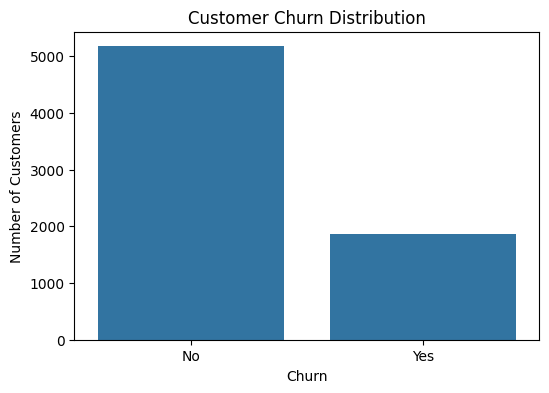

In [21]:
#churn visualization
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

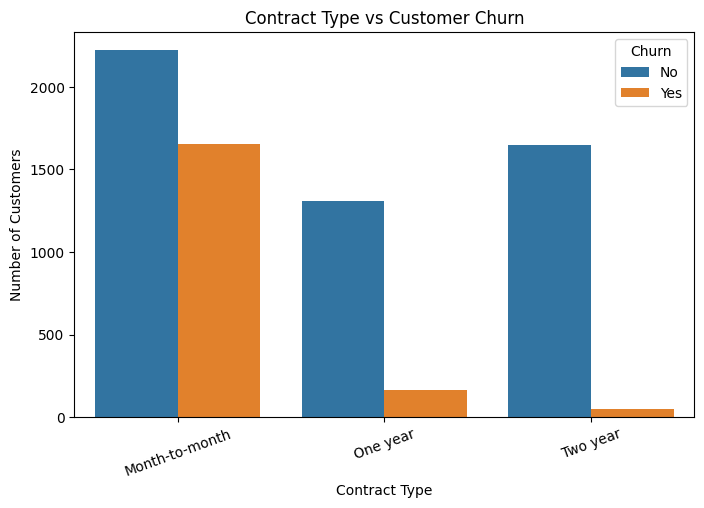

In [23]:
#contract type vs churn
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)
plt.show()


In [24]:
#churn percentage by contract
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


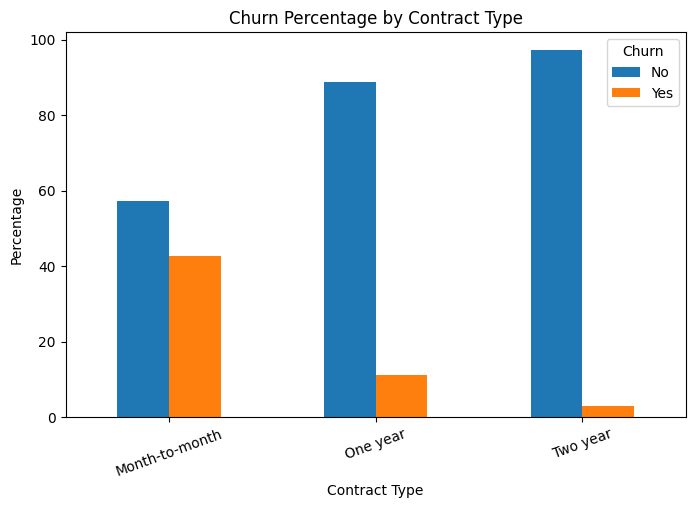

In [25]:
#visualization
contract_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn Percentage by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage")
plt.xticks(rotation=20)
plt.legend(title="Churn")
plt.show()

In [26]:
#tenure analysis
print(df["tenure"].describe())

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64


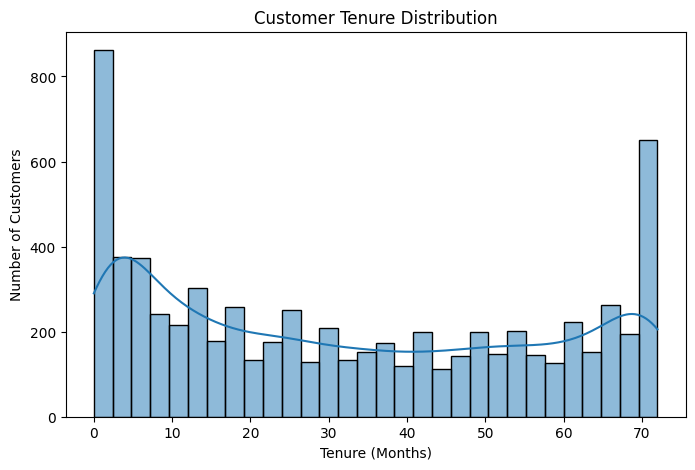

In [27]:
#tenure distribution
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="tenure", bins=30, kde=True)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

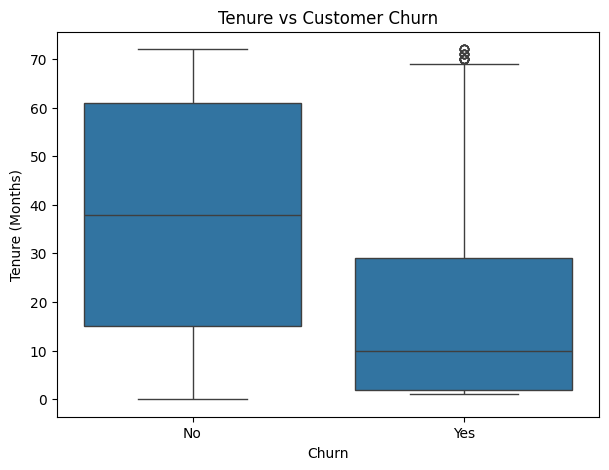

In [28]:
#tenure vs churn
plt.figure(figsize=(7,5))

sns.boxplot(data=df, x="Churn", y="tenure")

plt.title("Tenure vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

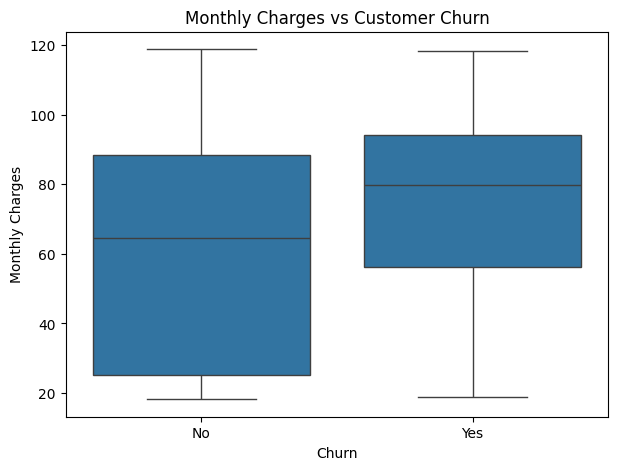

In [29]:
#monthly charges vs churn
plt.figure(figsize=(7,5))

sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

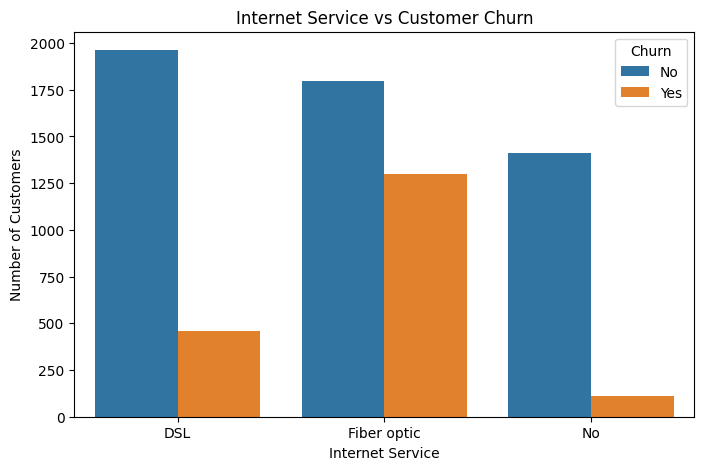

In [30]:
#churn by internet service
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="InternetService", hue="Churn")

plt.title("Internet Service vs Customer Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

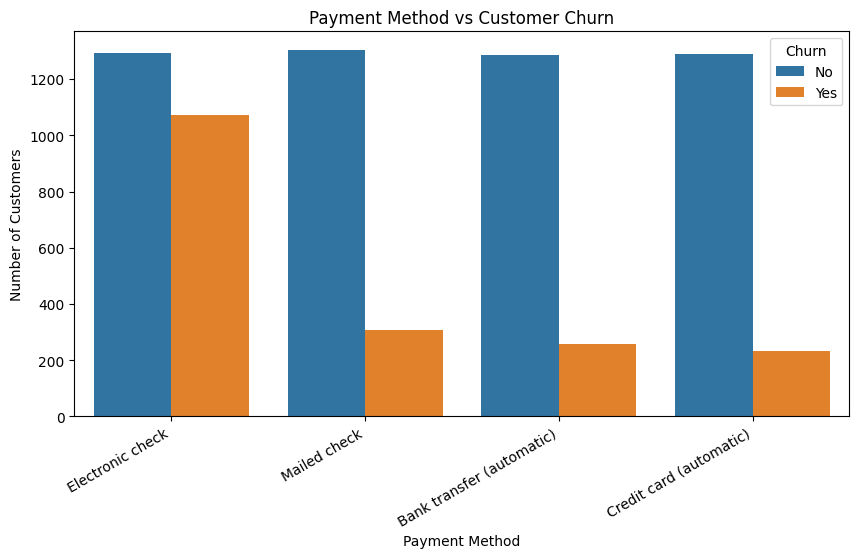

In [31]:
#churn by payment method
plt.figure(figsize=(10,5))

sns.countplot(data=df, x="PaymentMethod", hue="Churn")

plt.title("Payment Method vs Customer Churn")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30, ha="right")
plt.show()

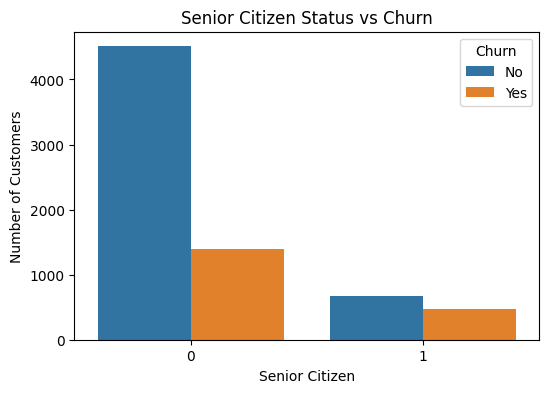

In [32]:
#churn by senior citizen
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="SeniorCitizen", hue="Churn")

plt.title("Senior Citizen Status vs Churn")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")

plt.show()

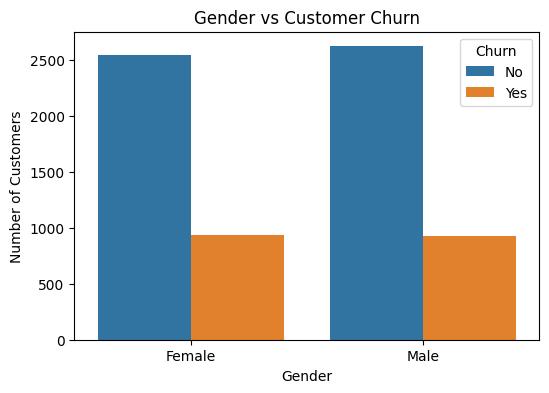

In [33]:
#churn by gender
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="gender", hue="Churn")

plt.title("Gender vs Customer Churn")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

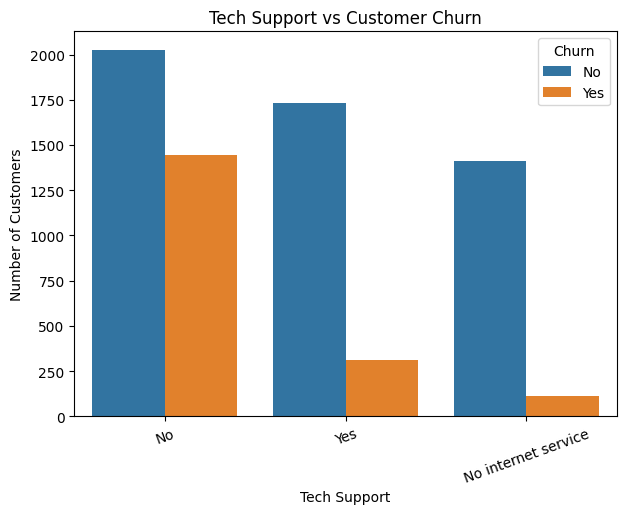

In [34]:
#churn by tech support
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="TechSupport", hue="Churn")

plt.title("Tech Support vs Customer Churn")
plt.xlabel("Tech Support")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)
plt.show()

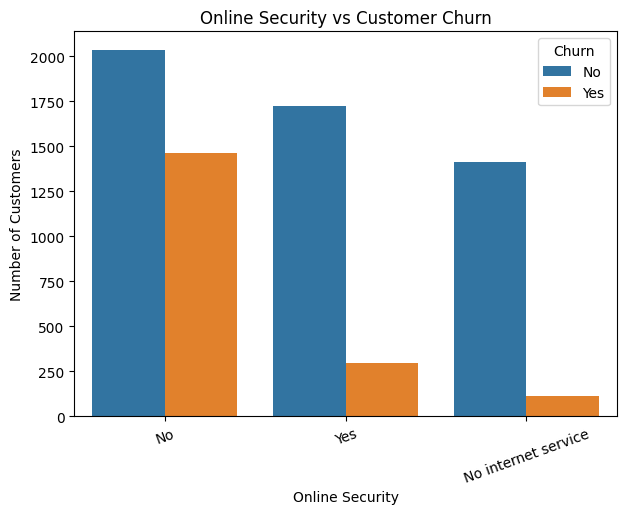

In [35]:
#churn by online security
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="OnlineSecurity", hue="Churn")

plt.title("Online Security vs Customer Churn")
plt.xlabel("Online Security")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)
plt.show()

In [36]:
#numerical colleration
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

correlation

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.102411
tenure,0.016567,1.000000,0.247900,0.825880
MonthlyCharges,0.220173,0.247900,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


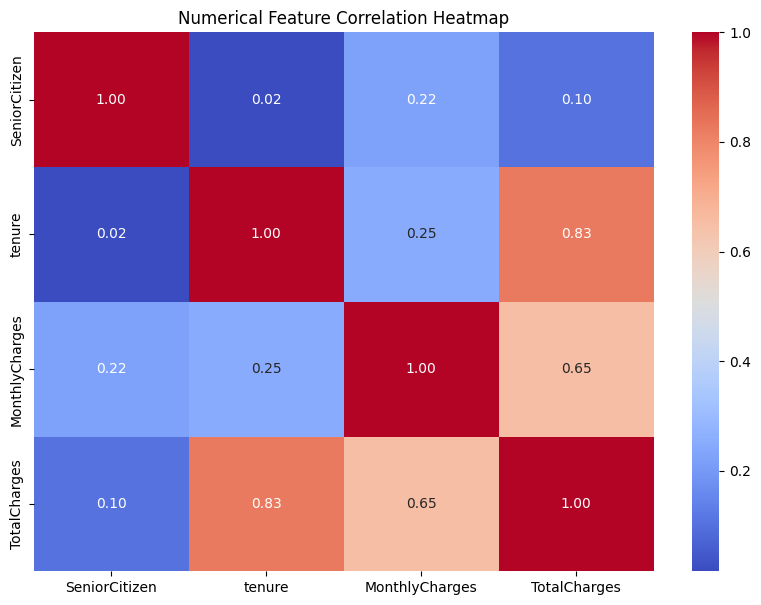

In [37]:
#correlation heatmap
plt.figure(figsize=(10,7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Numerical Feature Correlation Heatmap")

plt.show()

In [38]:
#tenure group
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12 Months", "13-24 Months", "25-48 Months", "49-72 Months"],
    include_lowest=True
)

df[["tenure", "TenureGroup", "Churn"]].head()

,tenure,TenureGroup,Churn
0,1,0-12 Months,No
1,34,25-48 Months,No
2,2,0-12 Months,Yes
3,45,25-48 Months,No
4,2,0-12 Months,Yes


In [39]:
#tenure group vs churn
tenure_churn = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
) * 100

tenure_churn

Churn,No,Yes
TenureGroup,,
0-12 Months,52.561757,47.438243
13-24 Months,71.289062,28.710938
25-48 Months,79.611041,20.388959
49-72 Months,90.486824,9.513176


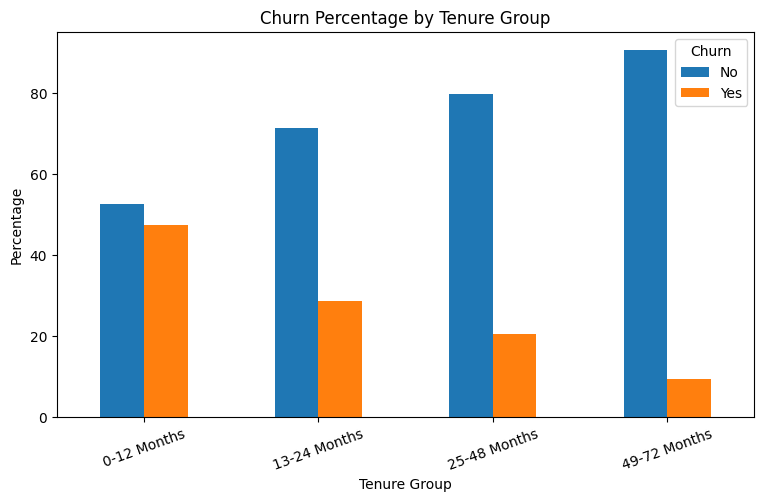

In [40]:
tenure_churn.plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Churn Percentage by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Percentage")

plt.xticks(rotation=20)
plt.legend(title="Churn")

plt.show()

In [41]:
#monthly charges groups
df["MonthlyChargeGroup"] = pd.cut(
    df["MonthlyCharges"],
    bins=[0, 40, 70, 100, np.inf],
    labels=["Low", "Medium", "High", "Very High"]
)

df[["MonthlyCharges", "MonthlyChargeGroup", "Churn"]].head()

,MonthlyCharges,MonthlyChargeGroup,Churn
0,29.85,Low,No
1,56.95,Medium,No
2,53.85,Medium,Yes
3,42.30,Medium,No
4,70.70,High,Yes


In [42]:
#monthly charges vs churn
charge_churn = pd.crosstab(
    df["MonthlyChargeGroup"],
    df["Churn"],
    normalize="index"
) * 100

charge_churn

Churn,No,Yes
MonthlyChargeGroup,,
Low,88.356910,11.643090
Medium,76.078915,23.921085
High,62.178292,37.821708
Very High,71.951220,28.048780


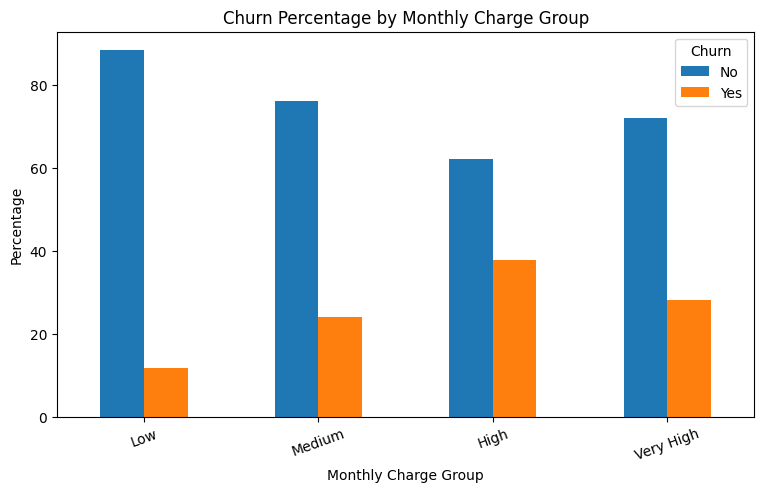

In [43]:
charge_churn.plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Churn Percentage by Monthly Charge Group")
plt.xlabel("Monthly Charge Group")
plt.ylabel("Percentage")

plt.xticks(rotation=20)
plt.legend(title="Churn")

plt.show()

# EDA Findings

## Key Observations

1. Customer churn varies across different contract types.
2. Tenure is an important factor associated with customer churn.
3. Customers with shorter tenure should be examined carefully for churn risk.
4. Monthly charges show differences between churned and retained customers.
5. Internet service, payment method, technical support and online security can also be associated with customer churn.
6. Correlation analysis helps identify relationships among numerical variables.

## Business Objective

The purpose of this EDA is to identify customer characteristics and service patterns associated with churn. These insights will be used in the next stages for feature engineering and predictive modeling.

# Customer Churn Prediction & LTV Engine
## Day 3–5: Exploratory Data Analysis (EDA)

### Objective
The objective of this analysis is to understand customer behavior and identify factors associated with customer churn.

### Key EDA Areas
- Customer churn distribution
- Contract type and churn
- Tenure and churn
- Monthly charges and churn
- Internet service and churn
- Payment method and churn
- Senior citizen status and churn
- Technical support and churn
- Online security and churn
- Numerical feature correlations

### Key Business Insights

1. **Churn distribution**
   The dataset shows the proportion of customers who churned compared with customers who remained with the company.

2. **Contract type**
   Contract type is an important factor to investigate because customers with different contract commitments can have different churn behavior.

3. **Tenure**
   Tenure helps identify how customer churn behavior changes with the length of the customer relationship.

4. **Monthly charges**
   Monthly charges can be compared between churned and retained customers to identify pricing-related patterns.

5. **Internet service**
   Internet service type can be analyzed to identify differences in churn behavior across service categories.

6. **Payment method**
   Payment method provides another customer behavior characteristic that can be examined for churn patterns.

7. **Customer services**
   Technical support and online security services can be compared with churn to identify potentially important retention factors.

8. **Correlation**
   Correlation analysis helps identify relationships between numerical variables and supports future feature engineering.

### Conclusion

The EDA provides a better understanding of customer characteristics and service-related factors associated with churn. These findings will be used in the next stage of the project for data preprocessing, feature engineering, and predictive modeling.